In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import smarts_cerebellum.globals as gl

df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI.tsv'), sep = '\t')

controls = ['CUP_1001', 'CUP_1002', 'JHP_1001', 'JHP_1002', 'JHP_1004']
metric = 'FaMap'
df = df[df.metric == metric]
df = df[~df.subj_id.isin(controls)]

region = ['CST']
regions = [f'{region[0]}_R', f'{region[0]}_L']
df = df[df.Object.isin(regions)]

/localscratch/tmp/ipykernel_56165/2872191366.py:9: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI.tsv'), sep = '\t')


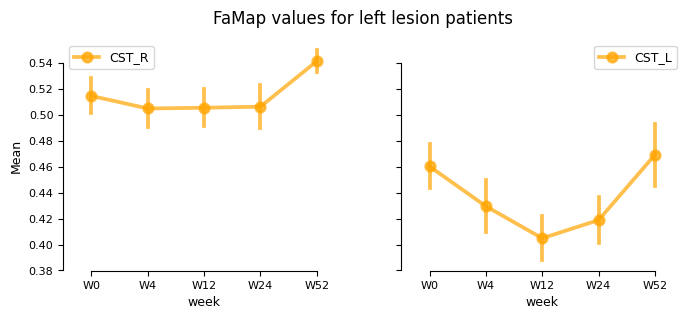

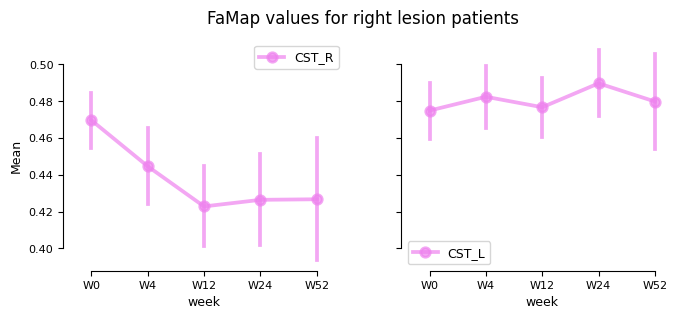

In [2]:
left_dti = df[df.LesionSide == 'left ']

fig, axs = plt.subplots(1, 2, figsize = (8,3), constrained_layout = False, sharey = True, sharex = True)
sns.pointplot(x = 'week', y = 'Mean', data = left_dti[left_dti['Object'] == regions[0]], alpha = .7, label = regions[0], color = 'orange', estimator = 'mean', ax = axs[0], errorbar = 'se')
sns.pointplot(x = 'week', y = 'Mean', data = left_dti[left_dti['Object'] == regions[1]], alpha = .7, label = regions[1], color = 'orange', estimator = 'mean', ax = axs[1], errorbar = 'se')


plt.suptitle(f"{metric} values for left lesion patients")
plt.legend()
sns.despine(trim = True)
plt.show()


right_dti = df[df.LesionSide == 'right']

fig, axs = plt.subplots(1, 2, figsize = (8,3), constrained_layout = False, sharey = True, sharex = True)
sns.pointplot(x = 'week', y = 'Mean', data = right_dti[right_dti['Object'] == regions[0]], alpha = .7, label = regions[0], color = 'violet', estimator = 'mean', ax = axs[0], errorbar = 'se')
sns.pointplot(x = 'week', y = 'Mean', data = right_dti[right_dti['Object'] == regions[1]], alpha = .7, label = regions[1], color = 'violet', estimator = 'mean', ax = axs[1], errorbar = 'se')


plt.suptitle(f"{metric} values for right lesion patients")
plt.legend()
sns.despine(trim = True)
plt.show()

In [6]:
print(f'---t-test between affected and unaffected CST in RIGHT lesion patients--- \n')

for week in right_dti.week.unique():
    t_val, p_val = stats.ttest_rel(right_dti[(right_dti.week == week) & (right_dti.Object == 'CST_R')]['Mean'], right_dti[(right_dti.week == week) & (right_dti.Object == 'CST_L')]['Mean'])
    print(f'Week {week}: t-value = {t_val}, p-value = {p_val} \n')
    

---t-test between affected and unaffected CST in RIGHT lesion patients--- 

Week W0: t-value = -1.3229199342945583, p-value = 0.2431325612967188 

Week W4: t-value = -3.8061503699242056, p-value = 0.003450879364361668 

Week W12: t-value = -3.3721855091355506, p-value = 0.008228385764273689 

Week W24: t-value = -3.8012918436358545, p-value = 0.004209007659457266 

Week W52: t-value = -2.7737518788118902, p-value = 0.032262137111114385 



In [7]:
print(f'---t-test between affected and unaffected CST in LEFT lesion patients--- \n')

for week in left_dti.week.unique():
    t_val, p_val = stats.ttest_rel(left_dti[(left_dti.week == week) & (left_dti.Object == 'CST_R')]['Mean'], left_dti[(left_dti.week == week) & (left_dti.Object == 'CST_L')]['Mean'])
    print(f'Week {week}: t-value = {t_val}, p-value = {p_val} \n')

---t-test between affected and unaffected CST in LEFT lesion patients--- 

Week W0: t-value = 5.132935311936446, p-value = 0.006824603880825988 

Week W4: t-value = 4.29829320313178, p-value = 0.007727957851939784 

Week W12: t-value = 5.904174951210046, p-value = 0.004118209008541343 

Week W24: t-value = 5.2811022043271345, p-value = 0.006165533583335293 

Week W52: t-value = 4.491094768573491, p-value = 0.02059978027261834 

